# 04 Statistical Analysis

Use this notebook for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [3]:
import pandas as pd
import seaborn as sns
import scipy.stats as stats

df = pd.read_csv("../data/processed/clean_retail_data.csv")

<Axes: >

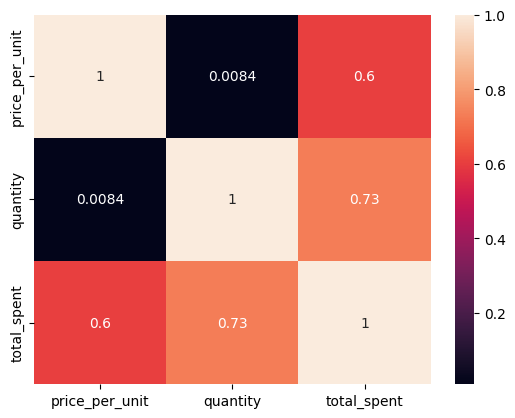

In [4]:
# Correlation Analysis
corr = df[["price_per_unit", "quantity", "total_spent"]].corr()
sns.heatmap(corr, annot=True)

                price_per_unit  quantity  total_spent
price_per_unit        1.000000  0.008390     0.601704
quantity              0.008390  1.000000     0.731243
total_spent           0.601704  0.731243     1.000000


<Axes: >

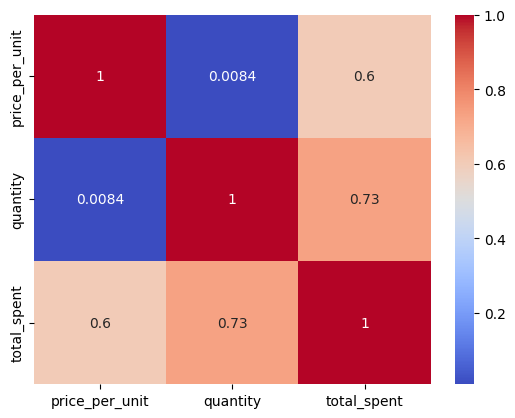

In [5]:
# Pearson Correlation
corr = df[["price_per_unit", "quantity", "total_spent"]].corr(method="pearson")
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm")

In [6]:
#Spearman Correlation
corr_spearman = df[["price_per_unit", "quantity", "total_spent"]].corr(method="spearman")
print(corr_spearman)

                price_per_unit  quantity  total_spent
price_per_unit        1.000000  0.008279     0.593400
quantity              0.008279  1.000000     0.766226
total_spent           0.593400  0.766226     1.000000


In [7]:
# RFM Analysis

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

rfm = df.groupby("customer_id").agg({
    "transaction_date": lambda x: (df["transaction_date"].max() - x.max()).days,
    "transaction_id": "count",
    "total_spent": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]
rfm.head()

,recency,frequency,monetary
customer_id,,,
CUST_01,0,507,59315.5
CUST_02,2,488,62588.0
CUST_03,2,465,61314.0
CUST_04,0,474,62230.0
CUST_05,4,544,67584.0


In [ ]:
# Distribution Skewness & Kurtosis
print("Skewness:", df["total_spent"].skew())
print("Kurtosis:", df["total_spent"].kurt())